## 0. Libraries

In [ ]:
# Import LoopDetect core and numpy
import numpy as np
import loopdetect.core as ld
import loopdetect.examples as lde
import numdifftools
import pandas as pd

from scipy.integrate import odeint
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## 1. Configuration

In [ ]:
from matplotlib import rcParams

rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "text.usetex": True,  # requires LaTeX installation
    "axes.linewidth": 1.2,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.major.size": 6,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
})

colors = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB']
colors_02 = ['#332288', '#117733', '#DDCC77', '#882255', '#AA4499', '#88CCEE', '#44AA99', '#999933', '#CC6677', '#DDDDDD']

## 2. Main reproduction

#### **Example 6: Calcium oscillations model**

The reactions (flows) constituting the model are given by
$$
\begin{aligned}
\nu_1 &= k_1,\\[6pt]
\nu_2 &= k_2,\\[6pt]
\nu_3 &= k_3 \cdot \frac{S_1^{n_1}}{kn_1^{\,n_1} + S_1^{n_1}},\\[10pt]
\nu_4 &= k_4 \cdot 
       \frac{S_2^{n_2}}{kn_2^{\,n_2} + S_2^{n_2}} \cdot
       \frac{S_1^{n_3}}{kn_3^{\,n_3} + S_1^{n_3}},\\[10pt]
\nu_5 &= k_5 \cdot S_2,\\[6pt]
\nu_6 &= k_6 \cdot S_1.
\end{aligned}
$$

The model is composed from these six reactions by
$$
\begin{aligned}
\frac{dS_1}{dt} &= \nu_1 + \nu_2 - \nu_3 + \nu_4 + \nu_5 - \nu_6,\\[6pt]
\frac{dS_2}{dt} &= \nu_3 - \nu_4 - \nu_5.
\end{aligned}
$$


In [4]:
def model_calcium_oscillation(y, klin, kn, n):
    S1, S2 = y
    k1, k2, k3, k4, k5, k6 = klin
    kn1, kn2, kn3 = kn
    n1, n2, n3 = n

    v1 = k1
    v2 = k2
    v3 = k3 * (S1**n1) / (kn1**n1 + S1**n1)
    v4 = k4 * (S2**n2)/(kn2**n2 + S2**n2) * (S1**n3)/(kn3**n3 + S1**n3)
    v5 = k5 * S2
    v6 = k6 * S1

    dS1 = v1 + v2 - v3 + v4 + v5 - v6
    dS2 = v3 - v4 - v5

    return np.array([dS1, dS2])

def solve_calcium_oscillation(initial_conditions, time_points, klin, kn, n):
    def model(t, x):
        return model_calcium_oscillation(x, klin, kn, n)
    sol = solve_ivp(model, [time_points[0], time_points[-1]], initial_conditions,
                    t_eval=time_points, method='RK45', rtol=1e-6)
    return sol

In [5]:
# Parameters from supplementary material
initial_conditions_calcium = [[0.3920, 1.6456]]
klin_calcium = [1, 7.3 * 0.4, 65, 500, 1, 10] # Fix k2 to 40% of original value as the new params from Prof. Baum
kn_calcium = [1, 2, 0.9]
n_calcium = [2, 2, 4]
time_points = np.linspace(0, 3, 301)

# Parameters not yet in supplement data
# perturbation_point = 0.2

In [6]:
initialize_time = np.linspace(0,8, 801)
sol = solve_calcium_oscillation(initial_conditions=initial_conditions_calcium[0],
                                time_points=initialize_time,
                                klin=klin_calcium,
                                kn=kn_calcium,
                                n=n_calcium)

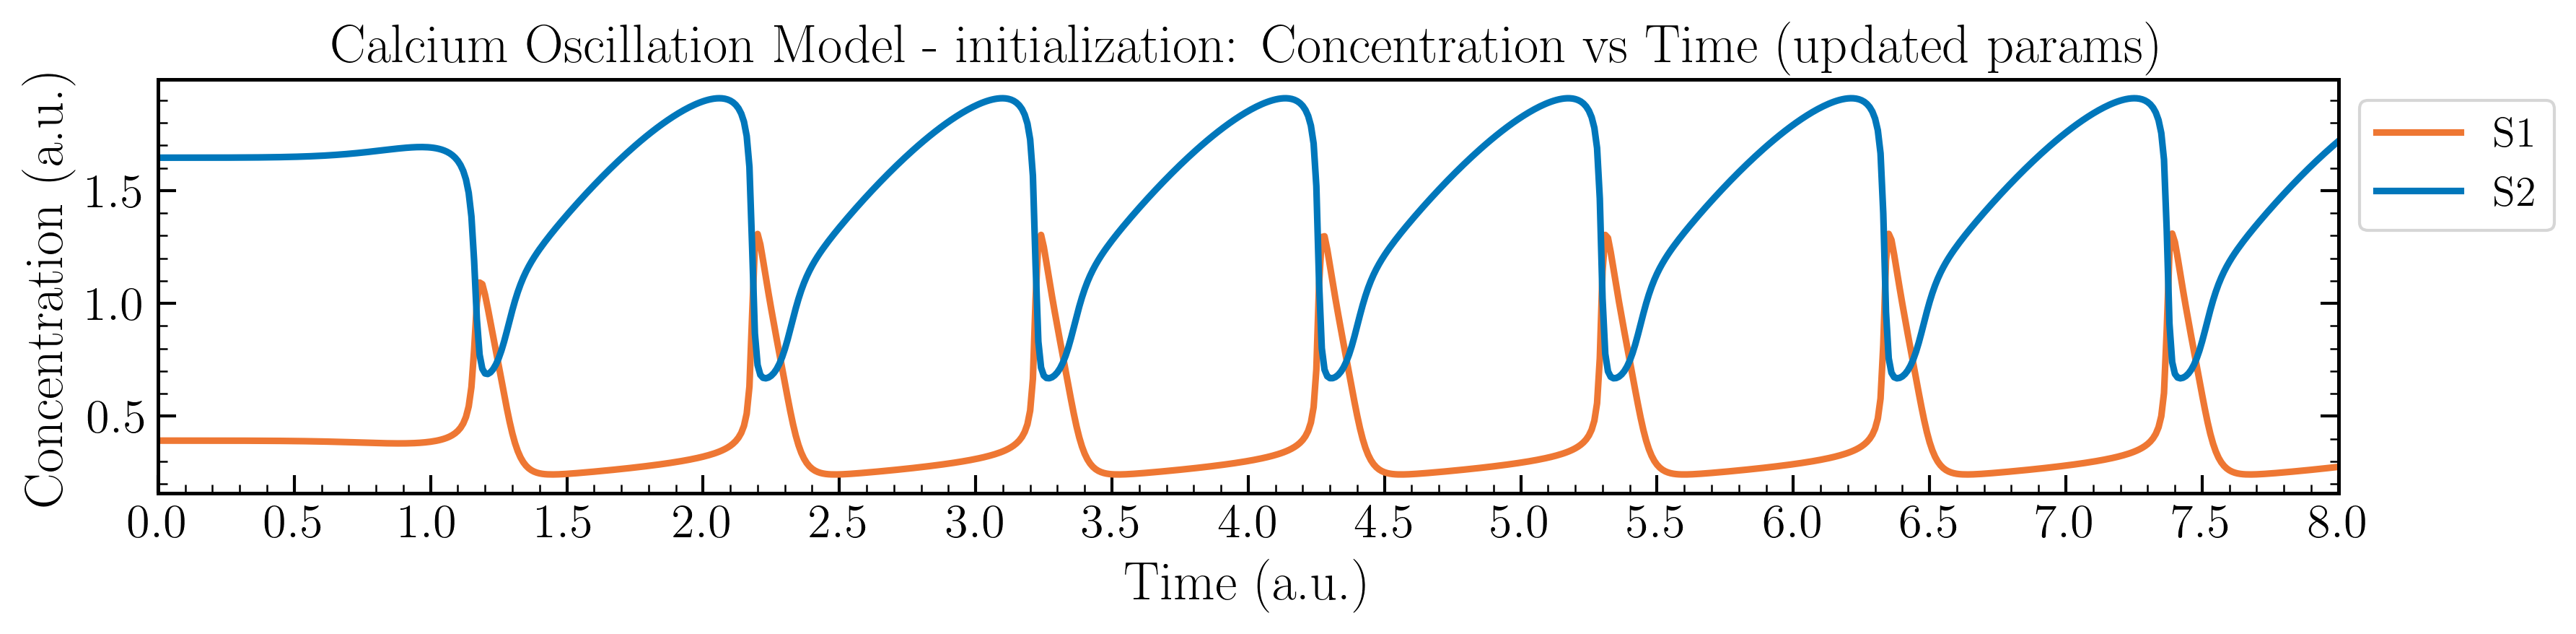

In [7]:
plt.figure(figsize=(12, 3))
for i, c in enumerate(colors[:2]):
    plt.plot(initialize_time, sol.y[i], lw=2.2, color=c, label=f"S{i+1}")
plt.xlabel('Time (a.u.)', weight='bold')
plt.xlim(0, 8)
plt.xticks(np.arange(0, 8.5, 0.5))
# Show tick marks in both left and right y-axes
plt.gca().yaxis.set_ticks_position('both')
plt.ylabel('Concentration (a.u.)', weight='bold')
# plt.yscale('log')
# plt.title(f'Parameters: {params}')
# Make legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.suptitle('Figure 2D Variations: Concentration vs Time for Old Model with Loops (fixed)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.title('Calcium Oscillation Model - initialization: Concentration vs Time (updated params)', weight='bold')
#Show in 300 dpi
plt.gcf().set_dpi(300)
plt.show()

In [8]:
sol = solve_calcium_oscillation(initial_conditions=sol.y[:, 264],
                                time_points=time_points,
                                klin=klin_calcium,
                                kn=kn_calcium,
                                n=n_calcium)

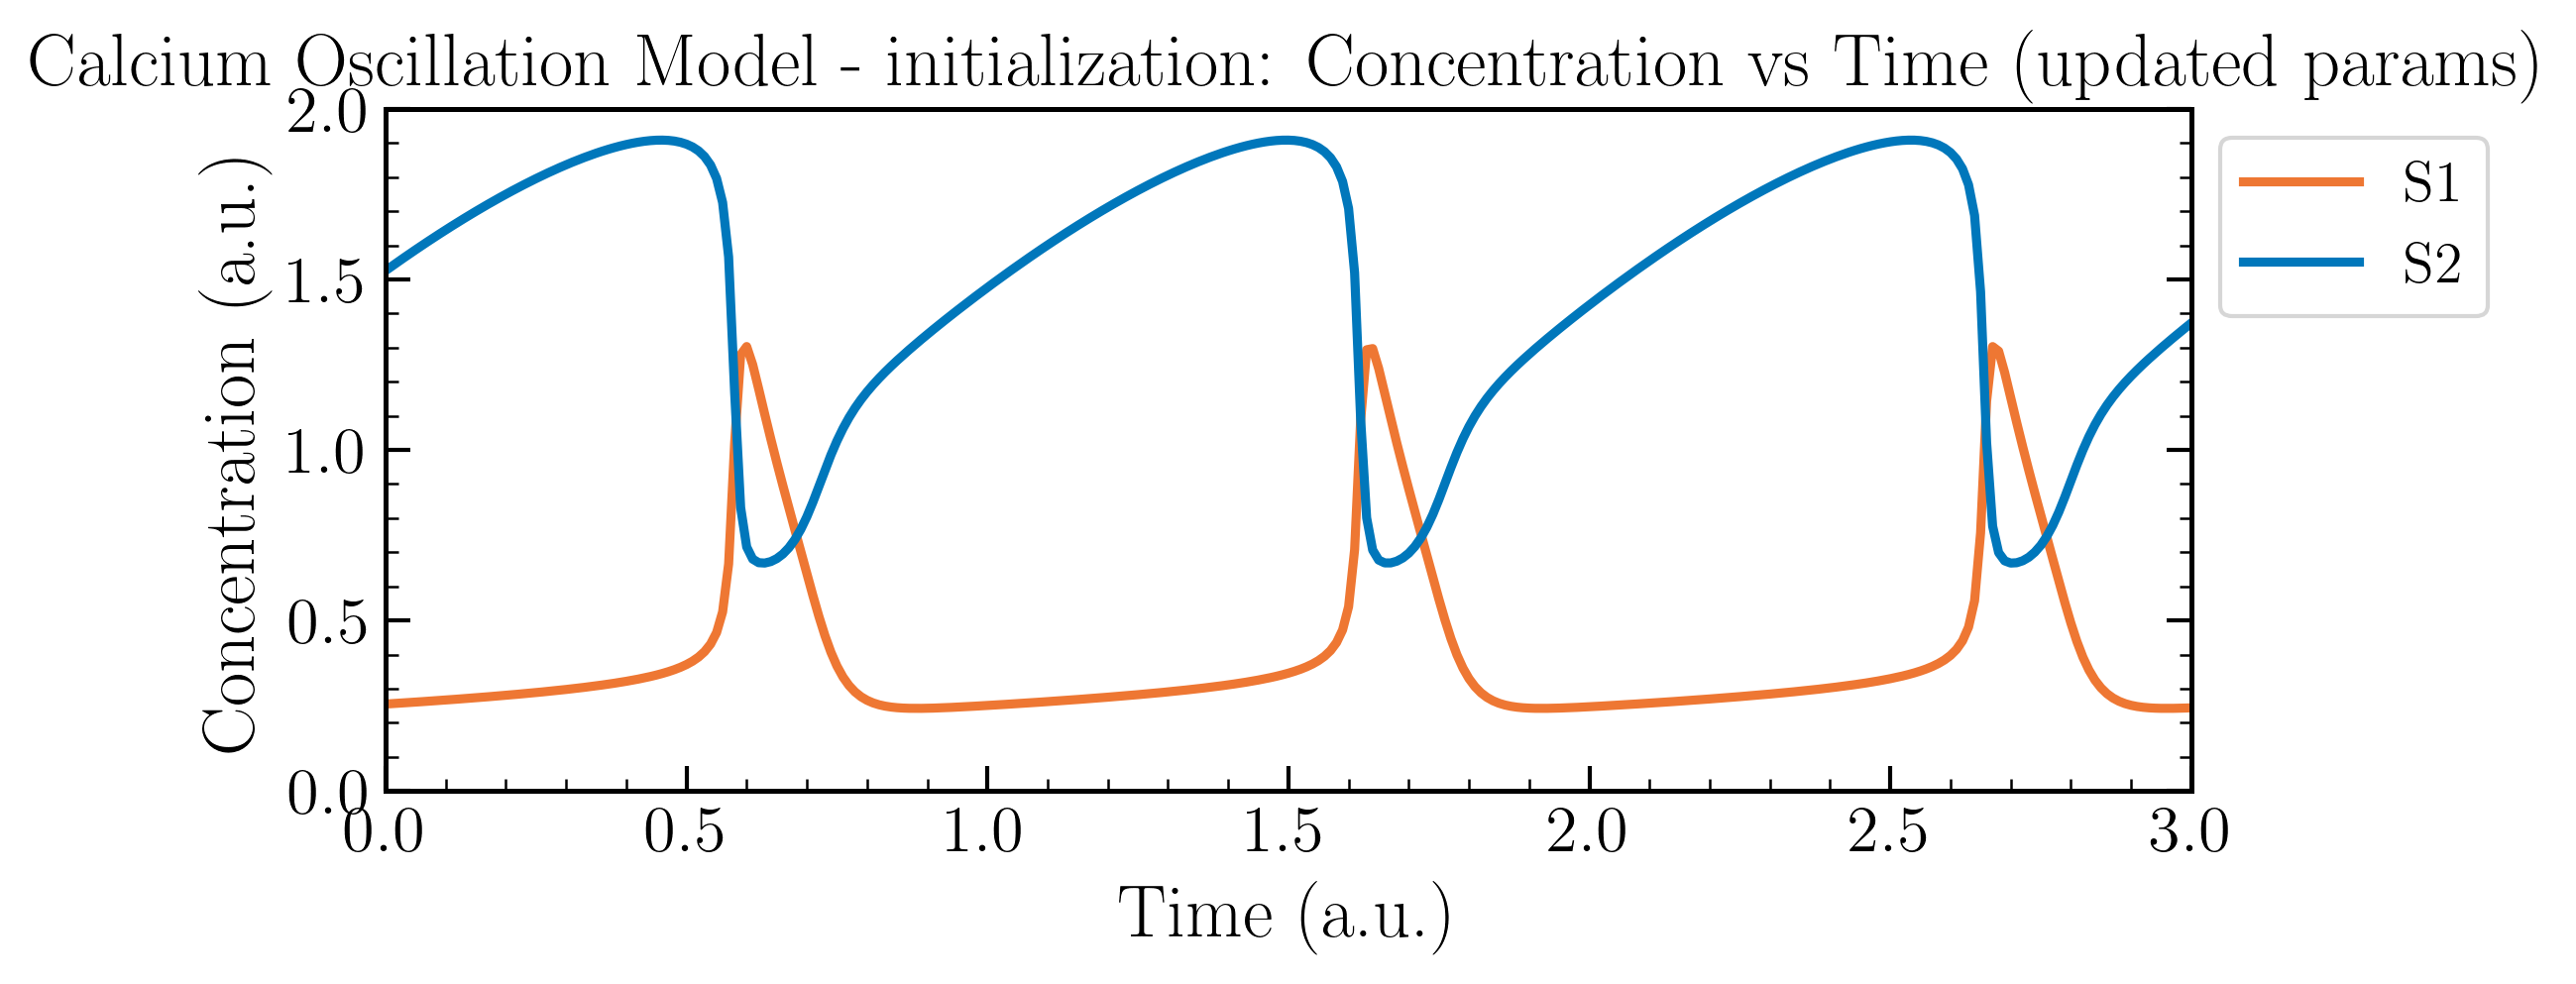

In [9]:
plt.figure(figsize=(8, 3.5))
for i, c in enumerate(colors[:2]):
    plt.plot(time_points, sol.y[i], lw=2.2, color=c, label=f"S{i+1}")
plt.xlabel('Time (a.u.)', weight='bold')
plt.xlim(0, 3)
plt.xticks(np.arange(0, 3.1, 0.5))
plt.ylim(0, 2)
plt.yticks(np.arange(0, 2.1, 0.5))
# Show tick marks in both left and right y-axes
plt.gca().yaxis.set_ticks_position('both')
plt.ylabel('Concentration (a.u.)', weight='bold')
# plt.yscale('log')
# plt.title(f'Parameters: {params}')
# Make legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.suptitle('Figure 2D Variations: Concentration vs Time for Old Model with Loops (fixed)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.title('Calcium Oscillation Model - initialization: Concentration vs Time (updated params)', weight='bold')
#Show in 300 dpi
plt.gcf().set_dpi(300)
plt.show()

In [10]:
# Detect loops structure changes along the trajectory, count the same loop structures by a dictionary (eg: 0: 10, 2: 5, ...)
j_0 = numdifftools.Jacobian(lambda x: model_calcium_oscillation(x, klin=klin_calcium, kn=kn_calcium, n=n_calcium),method="central")(sol.y[:, 0])
signed_jacobian_0 = np.sign(j_0)
initial_loop_list = ld.find_loops(j_0)
initial_loop_summary = ld.loop_summary(initial_loop_list)
J = numdifftools.Jacobian(
        lambda x: model_calcium_oscillation(x, klin=klin_calcium, kn=kn_calcium, n=n_calcium),
        method="central"
    )

In [13]:
loop_structures = {"Loop 0": 0}
loop_structures_j = [signed_jacobian_0.tolist()]
loop_structures_count = 0
loop_structures_time_range = {"Loop 0": []}

temp_j_signed = signed_jacobian_0
temp_start_time = sol.t[0]

for t_idx in range(sol.y.shape[1]):
    j_matrix_t = J(sol.y[:, t_idx])

    signed_jacobian_t = np.sign(j_matrix_t)

    if signed_jacobian_t.tolist() != temp_j_signed.tolist():
        # close segment for OLD structure
        temp_end_time = sol.t[t_idx - 1] if t_idx > 0 else sol.t[0]

        old_idx = loop_structures_j.index(temp_j_signed.tolist())
        loop_structures[f"Loop {old_idx}"] += 1
        loop_structures_time_range[f"Loop {old_idx}"].append((temp_start_time, temp_end_time))
        print(f"Idx (closed old): {old_idx}, Time Range: {temp_start_time:.2f} - {temp_end_time:.2f}")

        # now switch to NEW structure (create if needed)
        if signed_jacobian_t.tolist() in loop_structures_j:
            new_idx = loop_structures_j.index(signed_jacobian_t.tolist())
        else:
            loop_structures_j.append(signed_jacobian_t.tolist())
            loop_structures_count += 1
            new_idx = loop_structures_count
            loop_structures[f"Loop {new_idx}"] = 0
            loop_structures_time_range[f"Loop {new_idx}"] = []

        temp_j_signed = signed_jacobian_t
        temp_start_time = sol.t[t_idx]

    # end of loop: close final segment for CURRENT (temp_j_signed)
    if t_idx == sol.y.shape[1] - 1:
        temp_end_time = sol.t[t_idx]
        cur_idx = loop_structures_j.index(temp_j_signed.tolist())
        loop_structures[f"Loop {cur_idx}"] += 1
        loop_structures_time_range[f"Loop {cur_idx}"].append((temp_start_time, temp_end_time))
        print(f"Idx (end): {cur_idx}, Time Range: {temp_start_time:.2f} - {temp_end_time:.2f}")


Idx (closed old): 0, Time Range: 0.00 - 0.24
Idx (closed old): 1, Time Range: 0.25 - 0.38
Idx (closed old): 2, Time Range: 0.39 - 0.59
Idx (closed old): 1, Time Range: 0.60 - 0.63
Idx (closed old): 2, Time Range: 0.64 - 0.72
Idx (closed old): 1, Time Range: 0.73 - 0.73
Idx (closed old): 0, Time Range: 0.74 - 1.28
Idx (closed old): 1, Time Range: 1.29 - 1.41
Idx (closed old): 2, Time Range: 1.42 - 1.62
Idx (closed old): 1, Time Range: 1.63 - 1.66
Idx (closed old): 2, Time Range: 1.67 - 1.76
Idx (closed old): 1, Time Range: 1.77 - 1.77
Idx (closed old): 0, Time Range: 1.78 - 2.32
Idx (closed old): 1, Time Range: 2.33 - 2.45
Idx (closed old): 2, Time Range: 2.46 - 2.66
Idx (closed old): 1, Time Range: 2.67 - 2.70
Idx (closed old): 2, Time Range: 2.71 - 2.80
Idx (closed old): 1, Time Range: 2.81 - 2.81
Idx (end): 0, Time Range: 2.82 - 3.00


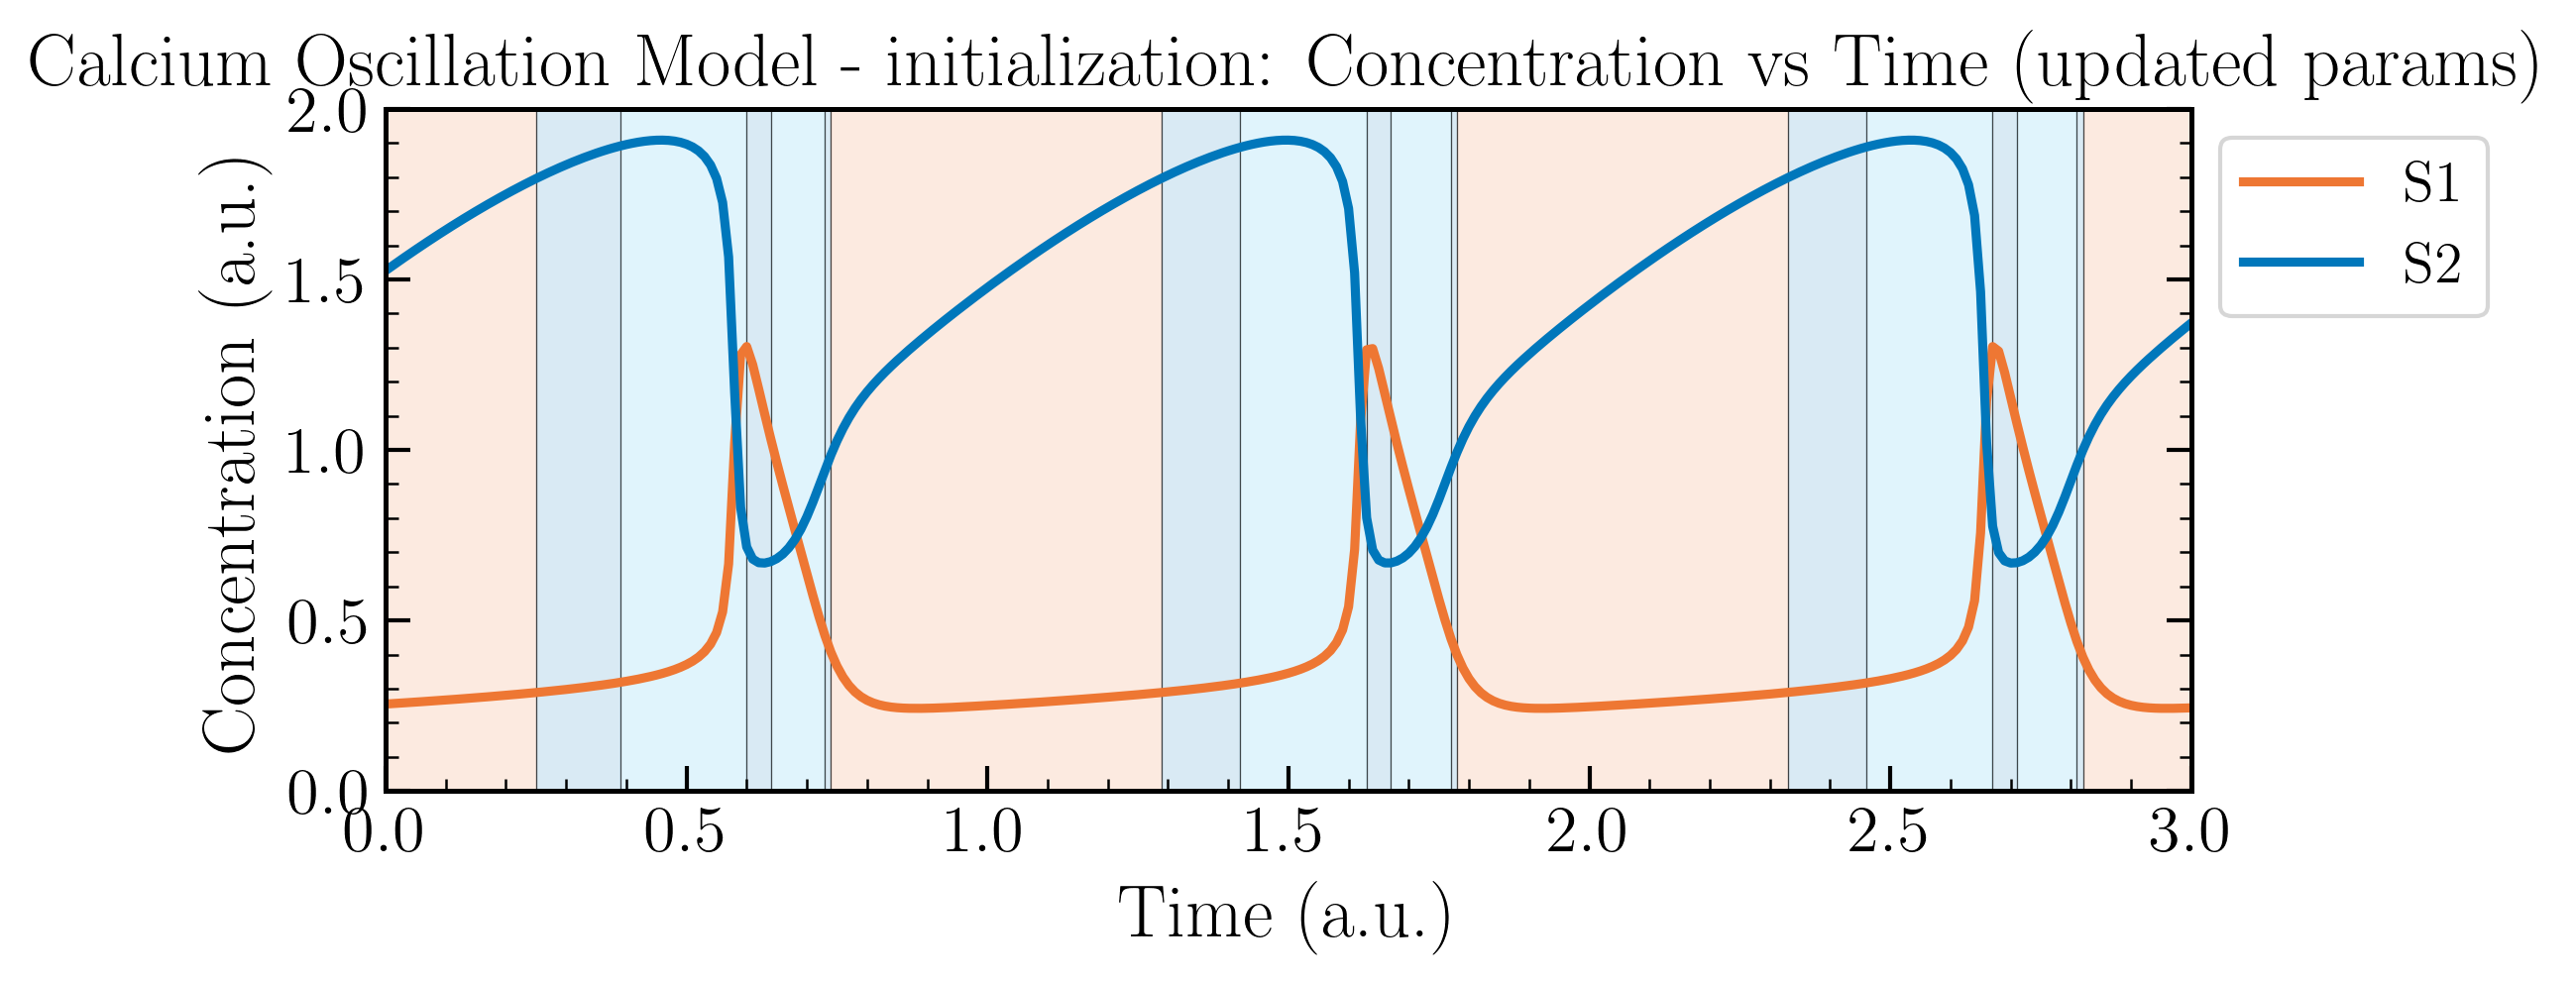

In [28]:
# Vizualize time ranges of different loop structures on the plot
plt.figure(figsize=(8, 3.5))
for loop_id, time_ranges in loop_structures_time_range.items():
    for (start, end) in time_ranges:
        plt.axvspan(start, end+0.01, alpha=0.15, color=colors[int(loop_id.split()[-1]) % len(colors)], lw=0.1)
        plt.axvline(x=end+0.01, color='black', lw=0.3, ls='-', alpha=0.7)
for i, c in enumerate(colors[:2]):
    plt.plot(time_points, sol.y[i], lw=2.2, color=c, label=f"S{i+1}")
plt.xlabel('Time (a.u.)', weight='bold')
plt.xlim(0, 3)
plt.xticks(np.arange(0, 3.1, 0.5))
plt.ylim(0, 2)
plt.yticks(np.arange(0, 2.1, 0.5))
# Show tick marks in both left and right y-axes
plt.gca().yaxis.set_ticks_position('both')
plt.ylabel('Concentration (a.u.)', weight='bold')
# plt.yscale('log')
# plt.title(f'Parameters: {params}')
# Make legend outside the plot
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
# plt.suptitle('Figure 2D Variations: Concentration vs Time for Old Model with Loops (fixed)')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.title('Calcium Oscillation Model - initialization: Concentration vs Time (updated params)', weight='bold')
#Show in 300 dpi
plt.gcf().set_dpi(300)
plt.show()

In [34]:
# Jacocbian calculation
print("Jacobian Matrix 0:")
print(signed_jacobian_0)

j_1 = numdifftools.Jacobian(lambda x: model_calcium_oscillation(x, klin=klin_calcium, kn=kn_calcium, n=n_calcium),method="central")(sol.y[:, 25])
signed_jacobian_1 = np.sign(j_1)
print("Jacobian Matrix 1:")
print(signed_jacobian_1)

j_2 = numdifftools.Jacobian(lambda x: model_calcium_oscillation(x, klin=klin_calcium, kn=kn_calcium, n=n_calcium),method="central")(sol.y[:, 39])
signed_jacobian_2 = np.sign(j_2)
print("Jacobian Matrix 2:")
print(signed_jacobian_2)

Jacobian Matrix 0:
[[-1.  1.]
 [ 1. -1.]]
Jacobian Matrix 1:
[[-1.  1.]
 [-1. -1.]]
Jacobian Matrix 2:
[[ 1.  1.]
 [-1. -1.]]


In [35]:
print("\nLoop summary 0:")
loop_list = ld.find_loops(j_0)
print(ld.loop_summary(loop_list))

print("\nLoop summary 1:")
loop_list = ld.find_loops(j_1)
print(ld.loop_summary(loop_list))

print("\nLoop summary 2:")
loop_list = ld.find_loops(j_2)
print(ld.loop_summary(loop_list))


Loop summary 0:
length  1  2
total   2  1
neg     2  0
pos     0  1

Loop summary 1:
length  1  2
total   2  1
neg     2  1
pos     0  0

Loop summary 2:
length  1  2
total   2  1
neg     1  1
pos     1  0


## 3. Additional features

### 3.1. Add subject ID to make the loop result more comprehensible

In [41]:
res_tab = ld.find_loops_vset(model_calcium_oscillation,
                             vset=[sol.y[:,-1]],
                            klin=klin_calcium,
                            kn=kn_calcium,
                            n=n_calcium,
                            max_num_loops=10)

id_to_subject = {
    0: "Ca (cyt)",
    1: "Ca (ER)"
}

df = pd.DataFrame(res_tab['loop_rep'][0]).sort_values(by=['length','loop'])

df["loop_subject"] = df["loop"].apply(
    lambda t: tuple(id_to_subject[i] for i in t)
)

df

,loop,length,sign,loop_subject
1,"(0, 0)",1,-1,"(Ca (cyt), Ca (cyt))"
2,"(1, 1)",1,-1,"(Ca (ER), Ca (ER))"
0,"(0, 1, 0)",2,1,"(Ca (cyt), Ca (ER), Ca (cyt))"


### 3.2. Represent regulation relationship from Jacobian matrix

In [42]:
# Dataframe with columns: 'from', 'to', 'regulation'
# Apply id to subject mapping

print("\nRegulation information for unstimulated conditions:")

regulation_info = pd.DataFrame(signed_jacobian_0, columns=[id_to_subject[i] for i in range(signed_jacobian_0.shape[1])], index=[id_to_subject[i] for i in range(signed_jacobian_0.shape[0])])
regulation_info = regulation_info.stack().reset_index()
regulation_info.columns = ['from', 'to', 'regulation']

# Add regulation information for each variable (-1: inhibition (negative), 1:activation (posotive)). 0 means no regulation and will not be shown in the graph.
regulation_info['regulation_words'] = regulation_info['regulation'].map({-1: 'inhibition (negative)', 1: 'activation (positive)', 0: 'no regulation'})
regulation_info


Regulation information for unstimulated conditions:


,from,to,regulation,regulation_words
0,Ca (cyt),Ca (cyt),-1.0,inhibition (negative)
1,Ca (cyt),Ca (ER),1.0,activation (positive)
2,Ca (ER),Ca (cyt),1.0,activation (positive)
3,Ca (ER),Ca (ER),-1.0,inhibition (negative)


### 3.3. Loop Summary in more detail

In [43]:
# Given dataframe from 3.1 named `df`
df

,loop,length,sign,loop_subject
1,"(0, 0)",1,-1,"(Ca (cyt), Ca (cyt))"
2,"(1, 1)",1,-1,"(Ca (ER), Ca (ER))"
0,"(0, 1, 0)",2,1,"(Ca (cyt), Ca (ER), Ca (cyt))"


In [44]:
# Loop summary (A different way)
loop_summary = df.groupby('length').agg(
    num_loops=('loop', 'count'),
    loops=('loop_subject', lambda x: list(x))
).reset_index()
loop_summary

,length,num_loops,loops
0,1,2,"[(Ca (cyt), Ca (cyt)), (Ca (ER), Ca (ER))]"
1,2,1,"[(Ca (cyt), Ca (ER), Ca (cyt))]"


In [45]:
# make an extended loop summary with added information: 'num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative'
# Loop positive if sign is positive, negative if sign is negative
def count_loop_types(loop_subjects, regulation_info):
    num_positive = 0
    num_negative = 0
    loops_positive = []
    loops_negative = []
    
    for loop in loop_subjects:
        sign = 1
        for i in range(len(loop)):
            from_node = loop[i]
            to_node = loop[(i + 1) % len(loop)]
            regulation = regulation_info[
                (regulation_info['from'] == from_node) & 
                (regulation_info['to'] == to_node)
            ]['regulation'].values[0]
            sign *= regulation
        if sign > 0:
            num_positive += 1
            loops_positive.append(loop)
        else:
            num_negative += 1
            loops_negative.append(loop)
    return num_positive, num_negative, loops_positive, loops_negative
loop_summary_extended = loop_summary.copy()
loop_summary_extended[['num_loops_positive', 'num_loops_negative', 'loops_positive', 'loops_negative']] = loop_summary_extended['loops'].apply(
    lambda x: pd.Series(count_loop_types(x, regulation_info))
)
loop_summary_extended

,length,num_loops,loops,num_loops_positive,num_loops_negative,loops_positive,loops_negative
0,1,2,"[(Ca (cyt), Ca (cyt)), (Ca (ER), Ca (ER))]",2,0,"[(Ca (cyt), Ca (cyt)), (Ca (ER), Ca (ER))]",[]
1,2,1,"[(Ca (cyt), Ca (ER), Ca (cyt))]",0,1,[],"[(Ca (cyt), Ca (ER), Ca (cyt))]"


In [46]:
# Columns can be rearranged based on preference
cols = ['length', 'num_loops', 'num_loops_positive', 'num_loops_negative', 'loops', 'loops_positive', 'loops_negative']
loop_summary_extended = loop_summary_extended[cols]
loop_summary_extended

,length,num_loops,num_loops_positive,num_loops_negative,loops,loops_positive,loops_negative
0,1,2,2,0,"[(Ca (cyt), Ca (cyt)), (Ca (ER), Ca (ER))]","[(Ca (cyt), Ca (cyt)), (Ca (ER), Ca (ER))]",[]
1,2,1,0,1,"[(Ca (cyt), Ca (ER), Ca (cyt))]",[],"[(Ca (cyt), Ca (ER), Ca (cyt))]"
